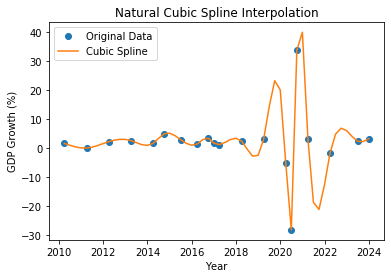

In [7]:
# Midterm Project overview:
# Use three methods, Least Squares, Polyfit, Cubic Spline

import numpy as np
import matplotlib.pyplot as plt
import random

# Data into arrays:
x = np.array([2010.25, 2011.25, 2012.25, 2013.25, 2014.25, 
              2014.75, 2015.50, 2016.25, 2016.75, 2017, 
              2017.25, 2018.25, 2019.25, 2020.25, 2020.50,
              2020.75, 2021.25, 2022.25, 2023.50, 2024])

# This is organized into year and quarter. For example, 2010.25 
# means year 2010 Q1, 2011.50 means 2011 Q2, and so on. 
# 2017 means 2016 Q4.
 
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 3.3, -1.6,
              2.4, 3.3])
# Data corresponding to the quarterly GDP growth rates.


# Tridiagonal system code 

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * (
            (y[i + 1] - y[i]) / h[i]
            - (y[i] - y[i - 1]) / h[i - 1]
        )

    return A, B, C, D, h

# Method to solve tridiagonal
def solve_tridiagonal(A, B, C, D):
    n = len(D)

    # Forward elimination
    for i in range(1, n):
        factor = A[i] / B[i - 1]
        B[i] = B[i] - factor * C[i - 1]
        D[i] = D[i] - factor * D[i - 1]

    # Back substitution
    M = np.zeros(n)
    M[-1] = D[-1] / B[-1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M

# Build second derivatives
A, B, C, D, h = setup_tridiagonal_matrix(x, y)

M_inner = solve_tridiagonal(A.copy(), B.copy(), C.copy(), D.copy())

# Add natural boundary conditions
M = np.zeros(len(x))
M[1:-1] = M_inner   # M0 = 0, Mn-1 = 0

# evaluate spline
def evaluate_spline(x, y, M, h, x_val):
    n = len(x)

    # Find correct interval
    for i in range(n - 1):
        if x[i] <= x_val <= x[i + 1]:
            break

    hi = h[i]

    term1 = M[i] * (x[i + 1] - x_val)**3 / (6 * hi)
    term2 = M[i + 1] * (x_val - x[i])**3 / (6 * hi)
    term3 = (y[i] - M[i] * hi**2 / 6) * (x[i + 1] - x_val) / hi
    term4 = (y[i + 1] - M[i + 1] * hi**2 / 6) * (x_val - x[i]) / hi

    return term1 + term2 + term3 + term4

# evaluate 

x_full = np.arange(2010.25, 2024.25, 0.25)
y_spline = np.zeros(len(x_full))

for i in range(len(x_full)):
    y_spline[i] = evaluate_spline(x, y, M, h, x_full[i])

# plotting figures-
plt.figure()
plt.plot(x, y, 'o', label='Original Data')
plt.plot(x_full, y_spline, label='Cubic Spline')
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.title("Natural Cubic Spline Interpolation")
plt.legend()
plt.show()

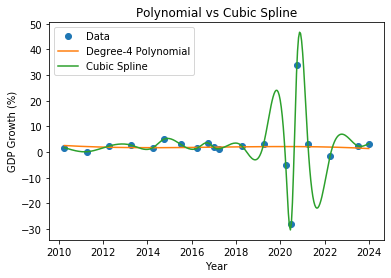

In [10]:
#polyfit setup, 4th degree

def custom_polyfit(x, y, degree):
    n = len(x)
    X = np.zeros((n, degree + 1))

    for i in range(n):
        for j in range(degree + 1):
            X[i][j] = x[i] ** j

    XT = X.T
    A = XT @ X
    b = XT @ y

    return np.linalg.solve(A, b)

def eval_poly(coeffs, x_val):
    total = 0
    for i in range(len(coeffs)):
        total += coeffs[i] * (x_val ** i)
    return total

# same cubic spline stuff
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * (
            (y[i + 1] - y[i]) / h[i]
            - (y[i] - y[i - 1]) / h[i - 1]
        )

    return A, B, C, D, h

def solve_tridiagonal(A, B, C, D):
    n = len(D)

    for i in range(1, n):
        factor = A[i] / B[i - 1]
        B[i] -= factor * C[i - 1]
        D[i] -= factor * D[i - 1]

    M = np.zeros(n)
    M[-1] = D[-1] / B[-1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M

def evaluate_spline(x, y, M, h, x_val):
    for i in range(len(x) - 1):
        if x[i] <= x_val <= x[i + 1]:
            break

    hi = h[i]

    term1 = M[i] * (x[i + 1] - x_val)**3 / (6 * hi)
    term2 = M[i + 1] * (x_val - x[i])**3 / (6 * hi)
    term3 = (y[i] - M[i] * hi**2 / 6) * (x[i + 1] - x_val) / hi
    term4 = (y[i + 1] - M[i + 1] * hi**2 / 6) * (x_val - x[i]) / hi

    return term1 + term2 + term3 + term4

# Build spline
A, B, C, D, h = setup_tridiagonal_matrix(x, y)
M_inner = solve_tridiagonal(A.copy(), B.copy(), C.copy(), D.copy())

M = np.zeros(len(x))
M[1:-1] = M_inner

# Build polyfit
coeffs = custom_polyfit(x, y, 4)

# Plot both
x_vals = np.linspace(min(x), max(x), 300)

y_poly = np.zeros(len(x_vals))
y_spline = np.zeros(len(x_vals))

for i in range(len(x_vals)):
    y_poly[i] = eval_poly(coeffs, x_vals[i])
    y_spline[i] = evaluate_spline(x, y, M, h, x_vals[i])

plt.figure()
plt.plot(x, y, 'o', label='Data')
plt.plot(x_vals, y_poly, label='Degree-4 Polynomial')
plt.plot(x_vals, y_spline, label='Cubic Spline')
plt.legend()
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.title("Polynomial vs Cubic Spline")
plt.show()

Slope (excluding COVID): -0.007627952755871531
Line: y = -0.007627952755871531x + 17.526470226309424


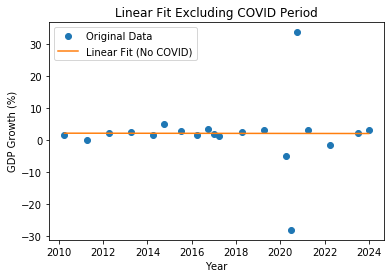

In [11]:
# REMOVE COVID PERIOD
# -----------------------------
x_filtered = []
y_filtered = []

for i in range(len(x)):
    if x[i] < 2020.25 or x[i] > 2021.25:
        x_filtered.append(x[i])
        y_filtered.append(y[i])

x_filtered = np.array(x_filtered)
y_filtered = np.array(y_filtered)

# -----------------------------
# LEAST SQUARES LINE
# -----------------------------
A = np.zeros((len(x_filtered), 2))

for i in range(len(x_filtered)):
    A[i][0] = x_filtered[i]
    A[i][1] = 1

def my_least_squares(A, b):
    At = A.T
    return np.linalg.solve(At @ A, At @ b)

m, c = my_least_squares(A, y_filtered)

print(f"Slope (excluding COVID): {m}")
print(f"Line: y = {m}x + {c}")

# -----------------------------
# PLOT
# -----------------------------
x_vals = np.linspace(min(x), max(x), 300)
y_line = m * x_vals + c

plt.figure()
plt.plot(x, y, 'o', label='Original Data')
plt.plot(x_vals, y_line, label='Linear Fit (No COVID)')
plt.legend()
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.title("Linear Fit Excluding COVID Period")
plt.show()